In [ ]:
%pip install networkx


In [22]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_csv('2008.csv')

print("Размер датасета:", df.shape)
print(df.head())
print(df.columns.tolist())

Размер датасета: (7009728, 29)
   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  2008      1           3          4   2003.0        1955   2211.0   
1  2008      1           3          4    754.0         735   1002.0   
2  2008      1           3          4    628.0         620    804.0   
3  2008      1           3          4    926.0         930   1054.0   
4  2008      1           3          4   1829.0        1755   1959.0   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiIn  TaxiOut  Cancelled  \
0        2225            WN        335  ...    4.0      8.0          0   
1        1000            WN       3231  ...    5.0     10.0          0   
2         750            WN        448  ...    3.0     17.0          0   
3        1100            WN       1746  ...    3.0      7.0          0   
4        1925            WN       3920  ...    3.0     10.0          0   

   CancellationCode  Diverted  CarrierDelay WeatherDelay NASDelay  \
0               NaN         

In [ ]:
# Предобработка данных
df = df.sort_values('DepTime')

df = df.dropna(subset=['Origin', 'Dest', 'DepTime'])

df['DepTime'] = df['DepTime'].astype(int)

df = df[['Origin', 'Dest', 'DepTime']]

print(f"После очистки осталось {len(df)} рейсов")
print(f"Количество уникальных аэропортов отправления: {df['Origin'].nunique()}")
print(f"Количество уникальных аэропортов назначения: {df['Dest'].nunique()}")

airports = list(set(df['Origin'].unique()) | set(df['Dest'].unique()))
print(f"Всего уникальных аэропортов: {len(airports)}")

print("\nданные после обработки:")
print(df.head())

После очистки осталось 6873482 рейсов
Количество уникальных аэропортов отправления: 303
Количество уникальных аэропортов назначения: 304
Всего уникальных аэропортов: 305

данные после обработки:
        Origin Dest  DepTime
4154296    ANC  DEN        1
1471301    LAS  BOS        1
4249217    PHX  SAN        1
3552845    LAS  BOS        1
6982869    EWR  PDX        1


In [ ]:
# Функция симуляции
def simulate_spread(df, start_city, infection_prob):
    infected = {}
    infected[start_city] = 0
    
    for idx, row in df.iterrows():
        origin = row['Origin']
        dest = row['Dest']
        time = int(row['DepTime'])  
        
        if origin in infected and dest not in infected:
            if np.random.random() < infection_prob:
                infected[dest] = time
    
    return infected

result = simulate_spread(df, airports[0], 0.5)
print(f"Заражено аэропортов: {len(result)} из {len(airports)}")
print("\nПервые 10 зараженных аэропортов:")
for i, (city, time) in enumerate(list(result.items())[:10]):
    print(f"{i+1}. {city}: заражен в момент времени {int(time)}")

Заражено аэропортов: 304 из 305

Первые 10 зараженных аэропортов:
1. ABE: заражен в момент времени 0
2. ORD: заражен в момент времени 546
3. IAH: заражен в момент времени 546
4. PHL: заражен в момент времени 546
5. ATL: заражен в момент времени 546
6. CLT: заражен в момент времени 547
7. SYR: заражен в момент времени 547
8. DFW: заражен в момент времени 547
9. IAD: заражен в момент времени 548
10. MSP: заражен в момент времени 548



вероятность 0.01...
  Симуляция 1/10
  Симуляция 6/10

вероятность 0.05...
  Симуляция 1/10
  Симуляция 6/10

вероятность 0.1...
  Симуляция 1/10
  Симуляция 6/10

вероятность 0.5...
  Симуляция 1/10
  Симуляция 6/10

вероятность 1.0...
  Симуляция 1/10
  Симуляция 6/10


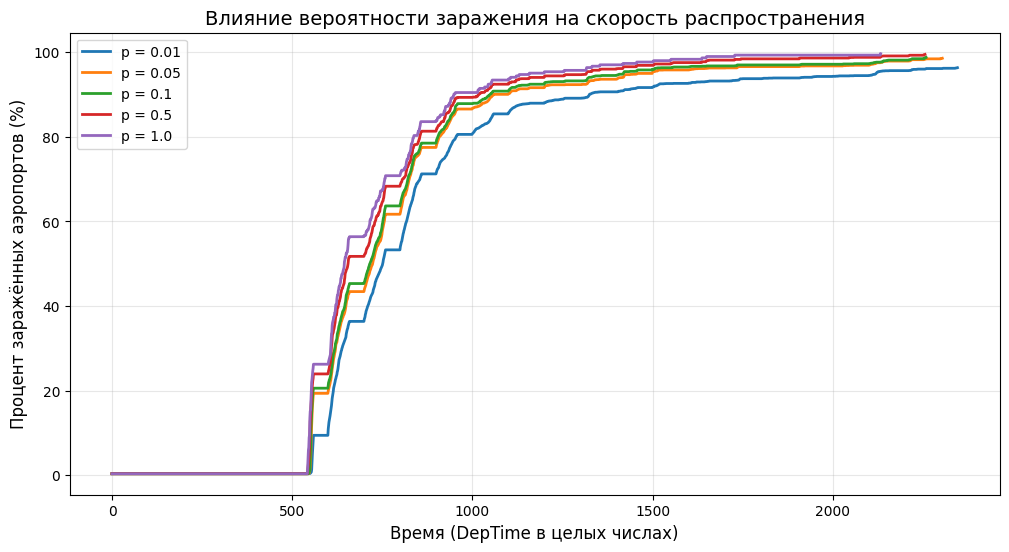

In [ ]:
# Влияние вероятности
probabilities = [0.01, 0.05, 0.1, 0.5, 1.0]
num_simulations = 10
total_airports = len(airports)

results_by_prob = {}

for prob in probabilities:
    print(f"\nвероятность {prob}...")
    all_infections = []
    
    for i in range(num_simulations):
        if i % 5 == 0:
            print(f"  Симуляция {i+1}/{num_simulations}")
        infections = simulate_spread(df, airports[0], prob)
        all_infections.append(infections)
    
    # Находим максимальное время 
    max_time = 0
    for infections in all_infections:
        for city, time in infections.items():
            current_time = int(time)  # Явно преобразуем в int
            if current_time > max_time:
                max_time = current_time
    
    max_time = int(max_time)
    
    percent_infected = []
    
    for t in range(max_time + 1):
        total_infected_now = 0
        
        for infections in all_infections:
            count = 0
            for city, infection_time in infections.items():
                if int(infection_time) <= t:  # Сравниваем с int
                    count += 1
            total_infected_now += count
        
        avg_percent = (total_infected_now / num_simulations) / total_airports * 100
        percent_infected.append(avg_percent)
    
    results_by_prob[prob] = percent_infected

plt.figure(figsize=(12, 6))
for prob in probabilities:
    plt.plot(results_by_prob[prob], label=f'p = {prob}', linewidth=2)

plt.xlabel('Время (DepTime в целых числах)', fontsize=12)
plt.ylabel('Процент заражённых аэропортов (%)', fontsize=12)
plt.title('Влияние вероятности заражения на скорость распространения', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Построение графа
G = nx.Graph()

flight_counter = {}

for idx, row in df.iterrows():
    city1 = row['Origin']
    city2 = row['Dest']
    pair = tuple(sorted([city1, city2]))
    
    if pair in flight_counter:
        flight_counter[pair] += 1
    else:
        flight_counter[pair] = 1

total_flights = len(df)
for (city1, city2), count in flight_counter.items():
    weight = count / total_flights
    G.add_edge(city1, city2, weight=weight)

print(f"Узлов (аэропортов) в графе: {G.number_of_nodes()}")
print(f"Рёбер (связей) в графе: {G.number_of_edges()}")
print(f"Плотность графа: {nx.density(G):.4f}")

Строим граф авиаперелетов...
Узлов (аэропортов) в графе: 305
Рёбер (связей) в графе: 2827
Плотность графа: 0.0610


In [36]:
# 50 симуляций и медианное время
num_simulations = 50
prob_fixed = 0.5
all_simulations = []

for i in range(num_simulations):
    if i % 10 == 0:
        print(f"Симуляция {i+1}/{num_simulations}")
    result = simulate_spread(df, airports[0], prob_fixed)
    all_simulations.append(result)

median_time = {}

for city in airports:
    infection_times = []
    
    for simulation in all_simulations:
        if city in simulation:
            infection_times.append(simulation[city])
    
    if infection_times:
        sorted_times = sorted(infection_times)
        middle = len(sorted_times) // 2
        median_time[city] = sorted_times[middle]
    else:
        median_time[city] = None

print("\nМедианное время заражения (первые 10 аэропортов):")
count = 0
for city, time in median_time.items():
    if time is not None:
        print(f"{city}: {time}")
        count += 1
        if count >= 10:
            break

Симуляция 1/50
Симуляция 11/50
Симуляция 21/50
Симуляция 31/50
Симуляция 41/50

Медианное время заражения (первые 10 аэропортов):
ABE: 0
JAC: 743
ROC: 601
SJT: 731
BRO: 825
SBP: 621
FNT: 714
GPT: 655
ADK: 1359
CAK: 645


In [51]:
# Расчет метрик графа

degree = dict(G.degree())

clustering = nx.clustering(G)

betweenness = nx.betweenness_centrality(G)

print("\nМетрики графа (первые 10 аэропортов):")
for i, city in enumerate(list(airports)[:10]):
    print(f"\n{city}:")
    print(f"  Степень: {degree.get(city, 0)}")
    print(f"  Кластеризация: {clustering.get(city, 0):.3f}")
    print(f"  Центральность: {betweenness.get(city, 0):.5f}")


Метрики графа (первые 10 аэропортов):

ABE:
  Степень: 12
  Кластеризация: 0.833
  Центральность: 0.00011

JAC:
  Степень: 9
  Кластеризация: 0.861
  Центральность: 0.00022

ROC:
  Степень: 18
  Кластеризация: 0.987
  Центральность: 0.00000

SJT:
  Степень: 1
  Кластеризация: 0.000
  Центральность: 0.00000

BRO:
  Степень: 1
  Кластеризация: 0.000
  Центральность: 0.00000

SBP:
  Степень: 9
  Кластеризация: 0.944
  Центральность: 0.00000

FNT:
  Степень: 12
  Кластеризация: 0.803
  Центральность: 0.00108

GPT:
  Степень: 7
  Кластеризация: 1.000
  Центральность: 0.00000

ADK:
  Степень: 1
  Кластеризация: 0.000
  Центральность: 0.00000

CAK:
  Степень: 14
  Кластеризация: 0.813
  Центральность: 0.00003


Анализируем 304 аэропортов


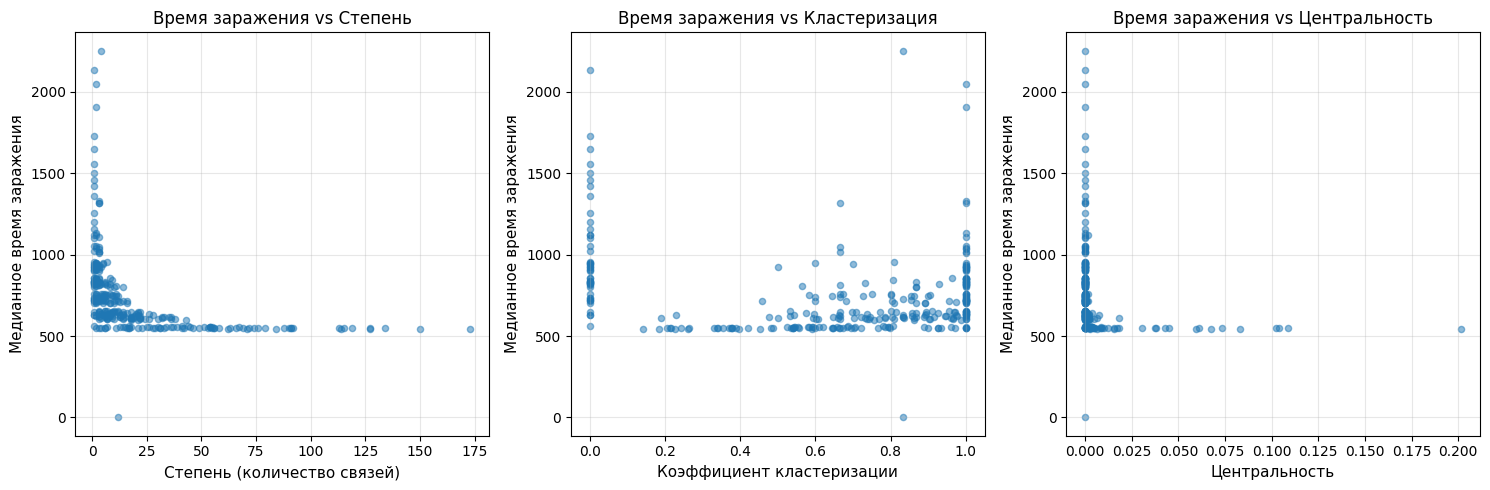

РЕЗУЛЬТАТЫ КОРРЕЛЯЦИИ СПИРМЕНА
Степень vs Время:        ρ = -0.807  (p = 0.0000)
Кластеризация vs Время:  ρ = 0.107  (p = 0.0620)
Центральность vs Время:  ρ = -0.706  (p = 0.0000)


In [52]:
# Построение графиков и корреляция
data = []

for city in airports:
    if median_time.get(city) is not None:
        data.append({
            'city': city,
            'time': median_time[city],
            'degree': degree.get(city, 0),
            'clustering': clustering.get(city, 0),
            'betweenness': betweenness.get(city, 0)
        })

df_metrics = pd.DataFrame(data)
print(f"Анализируем {len(df_metrics)} аэропортов")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df_metrics['degree'], df_metrics['time'], s=20, alpha=0.5)
axes[0].set_xlabel('Степень (количество связей)', fontsize=11)
axes[0].set_ylabel('Медианное время заражения', fontsize=11)
axes[0].set_title('Время заражения vs Степень', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_metrics['clustering'], df_metrics['time'], s=20, alpha=0.5)
axes[1].set_xlabel('Коэффициент кластеризации', fontsize=11)
axes[1].set_ylabel('Медианное время заражения', fontsize=11)
axes[1].set_title('Время заражения vs Кластеризация', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df_metrics['betweenness'], df_metrics['time'], s=20, alpha=0.5)
axes[2].set_xlabel('Центральность', fontsize=11)
axes[2].set_ylabel('Медианное время заражения', fontsize=11)
axes[2].set_title('Время заражения vs Центральность', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

corr_degree, p_degree = spearmanr(df_metrics['degree'], df_metrics['time'])
corr_clustering, p_clustering = spearmanr(df_metrics['clustering'], df_metrics['time'])
corr_betweenness, p_betweenness = spearmanr(df_metrics['betweenness'], df_metrics['time'])

print("РЕЗУЛЬТАТЫ КОРРЕЛЯЦИИ СПИРМЕНА")
print(f"Степень vs Время:        ρ = {corr_degree:.3f}  (p = {p_degree:.4f})")
print(f"Кластеризация vs Время:  ρ = {corr_clustering:.3f}  (p = {p_clustering:.4f})")
print(f"Центральность vs Время:  ρ = {corr_betweenness:.3f}  (p = {p_betweenness:.4f})")

In [53]:
print(f"""
Выводы: 
   • Степень и центральность показали СИЛЬНУЮ статистически значимую 
     корреляцию со временем заражения (p < 0.0001)
   • Коэффициент кластеризации не показал статистически значимой 
     корреляции (p = {p_clustering:.4f} > 0.05)

   -------------------------------------------------
   • Самая сильная корреляция у метрики "Степень" (ρ = {abs(corr_degree):.3f})
   • Чем больше у аэропорта прямых рейсов (связей), тем быстрее он заражается
   • Аэропорты-хабы находятся в зоне наибольшего риска
   • Кластеризация не влияет на скорость распространения инфекции

""")


Выводы: 
   • Степень и центральность показали СИЛЬНУЮ статистически значимую 
     корреляцию со временем заражения (p < 0.0001)
   • Коэффициент кластеризации не показал статистически значимой 
     корреляции (p = 0.0620 > 0.05)

   -------------------------------------------------
   • Самая сильная корреляция у метрики "Степень" (ρ = 0.807)
   • Чем больше у аэропорта прямых рейсов (связей), тем быстрее он заражается
   • Аэропорты-хабы находятся в зоне наибольшего риска
   • Кластеризация не влияет на скорость распространения инфекции




C:\temp\ipykernel_2240\2671700871.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


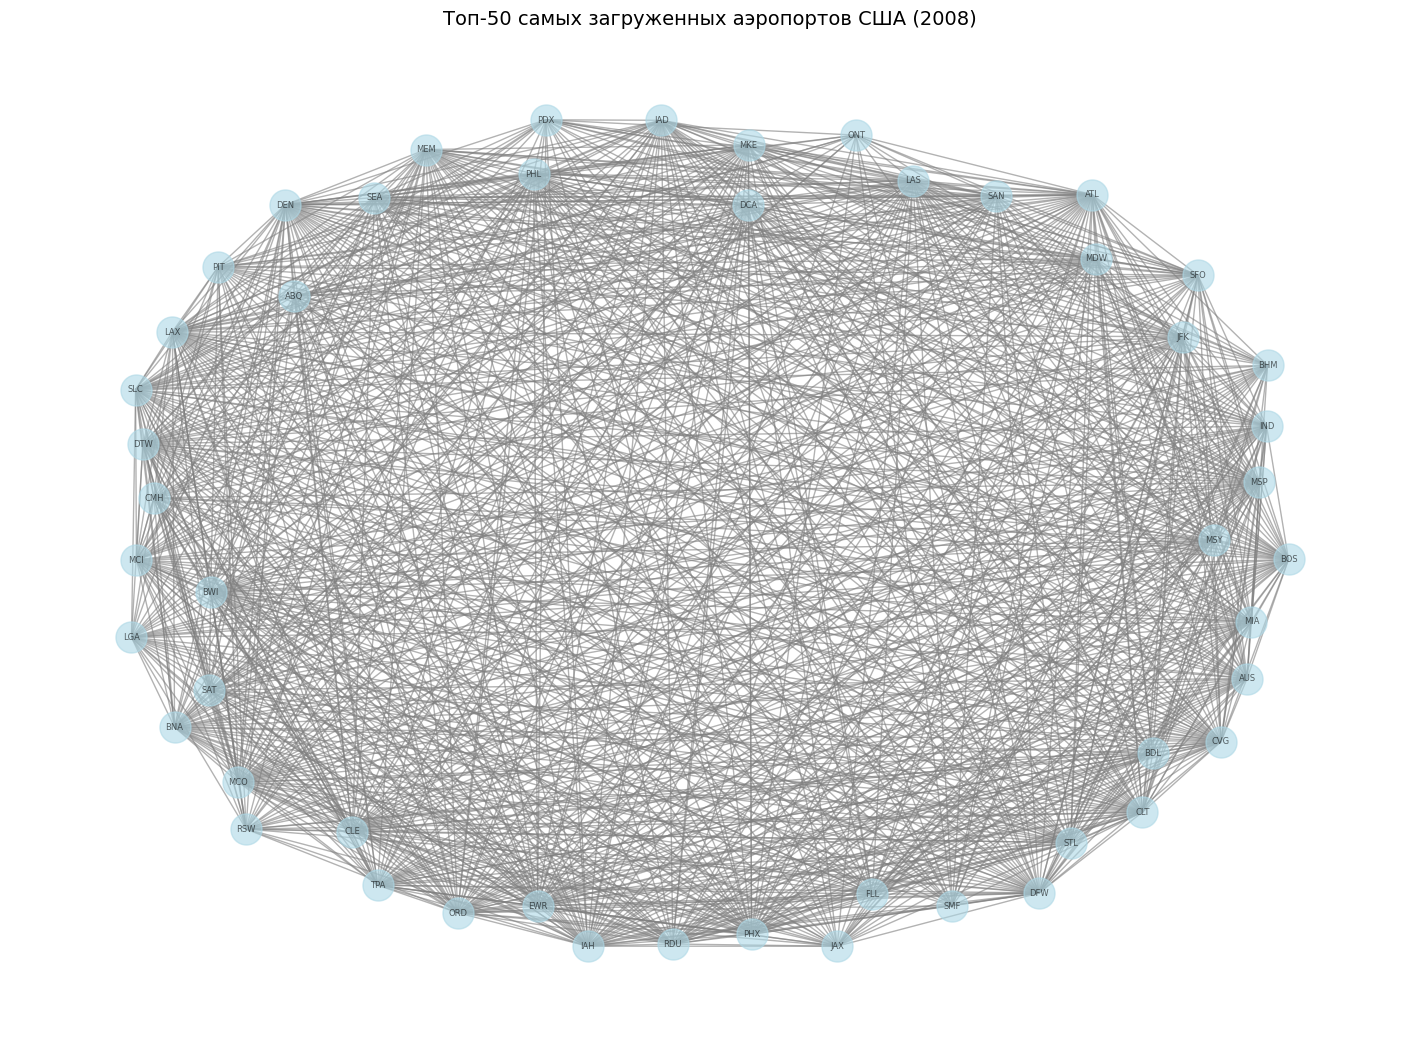


Крупнейшие аэропорты-хабы (по степени):
1. ATL: 173 связей
2. ORD: 150 связей
3. DFW: 134 связей
4. DEN: 127 связей
5. MSP: 127 связей
6. DTW: 119 связей
7. SLC: 115 связей
8. IAH: 114 связей
9. CVG: 113 связей
10. EWR: 92 связей


In [40]:
# Визуализация графа (первые 50 аэропортов)

top_nodes = sorted(degree, key=degree.get, reverse=True)[:50]
subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=2, seed=42)
nx.draw(subgraph, pos, 
        node_color='lightblue',
        node_size=500,
        with_labels=True,
        font_size=6,
        edge_color='gray',
        alpha=0.6)

plt.title("Топ-50 самых загруженных аэропортов США (2008)", fontsize=14)
plt.tight_layout()
plt.show()

print("\nКрупнейшие аэропорты-хабы (по степени):")
for i, (city, deg) in enumerate(list(sorted(degree.items(), key=lambda x: x[1], reverse=True))[:10]):
    print(f"{i+1}. {city}: {deg} связей")